# **Librerias y Funciones**

In [28]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.express as px

from ripser import ripser
from persim import plot_diagrams

from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette

In [30]:
#Función para calcular las matrices de Lance-Williams (LW)
def matrices_LW(X, method='complete'):
    #Calcular la primera matriz de distancias
    d_mat = squareform(pdist(X)).astype(float)
    c_sizes = np.ones(d_mat.shape[0])
    matrices = [d_mat.copy()]

    while d_mat.shape[0] > 2:
        m = d_mat.copy()
        np.fill_diagonal(m, np.inf)
        #Minima distancia
        min_val = np.min(m)
        if np.isinf(min_val): break

        # Encontrar todos las entradas cuya distancia sea la minima (clusters a fusionar)
        i_idx, j_idx = np.where(np.isclose(d_mat, min_val))

        #Fusionar clusters
        G = nx.Graph()
        G.add_nodes_from(range(d_mat.shape[0]))
        for i, j in zip(i_idx, j_idx):
            G.add_edge(i, j)

        components = [list(c) for c in nx.connected_components(G)]
        new_clusters = []

        for comp in components:
            new_clusters.append(comp)

        # Construir la siguiente matriz de distancia en base a la regla de iteración LW
        new_n = len(new_clusters)
        if new_n == d_mat.shape[0]: break

        new_d_mat = np.zeros((new_n, new_n))
        new_sizes = np.zeros(new_n)

        for i in range(new_n):
            new_sizes[i] = np.sum(c_sizes[new_clusters[i]])
            for j in range(i + 1, new_n):
                c1, c2 = new_clusters[i], new_clusters[j]

                if method == 'single':
                    d_val = np.min(d_mat[np.ix_(c1, c2)])
                elif method == 'complete':
                    d_val = np.max(d_mat[np.ix_(c1, c2)])
                elif method == 'average':
                    d_val = np.mean(d_mat[np.ix_(c1, c2)])
                    
                new_d_mat[i, j] = new_d_mat[j, i] = d_val

        d_mat = new_d_mat
        matrices.append(d_mat.copy())

    return matrices

#Funcion para obtener la holografía jerárquica a partir de las matrices LW
def holografia(mats, maxDim=1):
    #mats son las matrices LW
    n = len(mats)
    if n == 1: axes = [axes]

    diagramas=[]
    num_clusters=[]
    #Calcular el diagrama de persistencia para cada matriz LW
    for i, m in enumerate(mats):
        dgms = ripser(m, distance_matrix=True, maxdim=maxDim)['dgms']
        diagramas.append(dgms)
        num_clusters.append(m.shape[0])

    return diagramas, num_clusters

#Función para graficar el diagrama de persistencia
def graficar_diag(dgms,titulo):
  fig, ax = plt.subplots(figsize=(7, 7))

  max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
  ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

  x_vals = np.linspace(0, max_val, 100)
  ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

  colors = ['#2AA58B', '#804C80', '#D6AF51', '#c0392b']
  labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

  for i, dgm in enumerate(dgms):
      if dgm.size > 0:
          clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

          ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                    color=colors[i],
                    label=labels[i],
                    s=80,
                    alpha=0.8,
                    edgecolors='none')

  ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
  ax.set_xlim(-0.03*max_val, max_val)
  ax.set_ylim(0, max_val)
  ax.set_xlabel('Nacimiento', fontsize=15)
  ax.set_ylabel('Muerte', fontsize=15)
  ax.set_title(f'{titulo}', fontsize=15)
  ax.legend()
  plt.show()

# **Importe y Conversión de los Datos**

In [3]:
#Leer el archivo del conectoma
df_conn = pd.read_csv("Connectome.csv", header=None)
df_conn

,0,1,2,3,4
0,NaN,Neuron,Target,Number of Connections,Neurotransmitter
1,0.0,ADAL,AIBL,1.0,exc
2,1.0,ADAL,AIBR,2.0,exc
3,2.0,ADAL,AVAR,2.0,exc
4,3.0,ADAL,AVBL,4.0,exc
...,...,...,...,...,...
2275,2274.0,VC1,DD3,6.0,exc
2276,2275.0,VC1,DVC,1.0,exc
2277,2276.0,VC1,PVT,2.0,exc
2278,2277.0,VC1,VC2,3.0,exc


In [5]:
#Cambiar los nombres de la primera fila
df_conn = pd.read_csv(
    "Connectome.csv", 
    sep=',', 
    skiprows=1, 
    header=None, 
    names=['Index', 'Neuron', 'Target', 'Connections', 'Neurotransmitter']
)

#Eliminar filas que tengan NaN en columnas
df_conn = df_conn.dropna(subset=['Neuron', 'Target'])

#Construir el grafo usando las columnas limpias
G = nx.Graph()

for idx, row in df_conn.iterrows():
    origen = str(row['Neuron']).strip()
    destino = str(row['Target']).strip()
    
    # Usamos el número de conexiones como peso
    peso = float(row['Connections'])
    
    distancia_enlace = 1.0 / peso
    
    G.add_edge(origen, destino, weight=distancia_enlace)

# Calcular caminos más cortos considerando el peso de las conexiones
path_lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

# Ordenar las neuronas alfabéticamente
nodos = sorted(list(G.nodes()))
n_nodes = len(nodos)

# Crear la matriz de distancias
dist_matrix_neurons = np.zeros((n_nodes, n_nodes))
nodo_a_idx = {nodo: i for i, nodo in enumerate(nodos)}

# Penalización por si hay componentes aisladas 
max_penalizacion = 10.0

for u in nodos:
    for v in nodos:
        i, j = nodo_a_idx[u], nodo_a_idx[v]
        dist_matrix_neurons[i, j] = path_lengths[u].get(v, max_penalizacion)

# Encajar la matriz de distancias a un espacio continuo euclidiano
mds = MDS(n_components=3, dissimilarity='precomputed', random_state=42)
datos = mds.fit_transform(dist_matrix_neurons)

/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


# **Visualización de los Datos**

In [15]:
#Calculamos el PCA de dimensión tres
pca = PCA(n_components=3)
datos_pca = pca.fit_transform(datos)

df = pd.DataFrame(datos_pca)

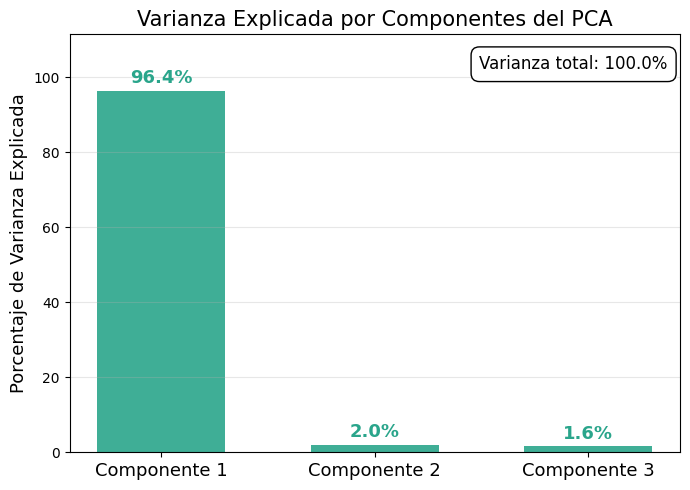

In [16]:
# Varianza explicada del PCA
varianza_explicada = pca.explained_variance_ratio_
varianza_total = sum(varianza_explicada) * 100

plt.figure(figsize=(7, 5))

x = [1, 2, 3]
y = varianza_explicada * 100
bars = plt.bar(x, y, alpha=0.9, color='#2AA58B', width=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=13, color="#2AA58B", fontweight='bold')

plt.xticks([1, 2, 3], ['Componente 1', 'Componente 2', 'Componente 3'], fontsize=13)
plt.ylabel('Porcentaje de Varianza Explicada', fontsize=13)
plt.title(f'Varianza Explicada por Componentes del PCA', fontsize=15)
plt.grid(axis='y', alpha=0.3)

plt.text(0.98, 0.95, f'Varianza total: {varianza_total:.1f}%',
         transform=plt.gca().transAxes,
         ha='right', va='top',
         fontsize=12,
         bbox=dict(facecolor='white', alpha=1, edgecolor='black', boxstyle='round,pad=0.5'))

plt.ylim(0, max(y) + 15)
plt.tight_layout()
plt.savefig(f"Varianza PCA Neuronas.png", dpi=300, bbox_inches='tight')
plt.show()

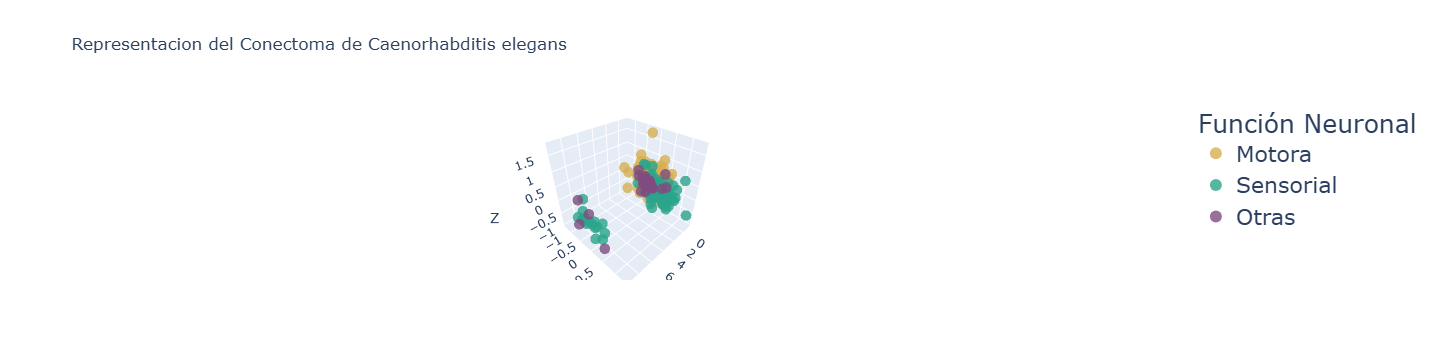

In [17]:
neuro_map = dict(zip(df_conn['Neuron'], df_conn['Neurotransmitter']))

df_plot = pd.DataFrame({
    'X': datos_pca[:, 0],
    'Y': datos_pca[:, 1],
    'Z': datos_pca[:, 2],
    'Neuron_Name': nodos
})

df_plot['Neurotransmitter'] = df_plot['Neuron_Name'].map(neuro_map).fillna('unknown')

#Clasificación de la funcionalidad de las neurona en base a la primera o ultima letra de su nombre
def clasificar_por_nombre(nombre):
    nombre = str(nombre).upper()
    if nombre.startswith('A') or nombre.startswith('V') or nombre.startswith('P'):
        return 'Motora'
    elif nombre.startswith('S') or nombre.startswith('I') or nombre.endswith('L') or nombre.endswith('R'):
        return 'Sensorial '
    else:
        return 'Otras'

#Graficamos PCA con la asignación de las funciones de cada neurona
df_plot['Funcion Neuronal'] = df_plot['Neuron_Name'].apply(clasificar_por_nombre)

fig_func = px.scatter_3d(
    df_plot, x='X', y='Y', z='Z',
    color='Funcion Neuronal',
    hover_name='Neuron_Name',
    title='Representacion del Conectoma de Caenorhabditis elegans',
    color_discrete_sequence=[ '#D6AF51', '#2AA58B', '#804C80']
)
fig_func.update_traces(marker=dict(size=6, opacity=0.8))
fig_func.update_layout(
    legend=dict(
        title=dict(
            text="Función Neuronal",
            font=dict(size=25)  
        ),
        font=dict(
            size=22  
        ),
        itemsizing="constant"  
    )
)
fig_func.write_html("tunel_somatico.html")
fig_func.show()

In [19]:
#Separamos los datos en dos clusters
kmeans_macro = KMeans(n_clusters=2, random_state=42).fit(datos)
etiquetas_macro = kmeans_macro.labels_

datos_cluster_0 = datos[etiquetas_macro == 0]
datos_cluster_1 = datos[etiquetas_macro == 1]

/lustre/home/jmolina/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [33]:
#Graficamos cada cluster por separado
df_plot['Cluster_ID'] = etiquetas_macro

df_cluster_0 = df_plot[df_plot['Cluster_ID'] == 0].copy()
df_cluster_1 = df_plot[df_plot['Cluster_ID'] == 1].copy()

print(f"Neuronas en el Clúster 0: {df_cluster_0.shape[0]}")
print(f"Neuronas en el Clúster 1: {df_cluster_1.shape[0]}")

fig_c0 = px.scatter_3d(
    df_cluster_0, x='X', y='Y', z='Z',
    color='Funcion Neuronal',
    hover_name='Neuron_Name',
    title='Sub-Anatomía del Clúster 0',
    color_discrete_sequence=['#D6AF51', '#2AA58B', '#804C80']
)

fig_c0.update_traces(marker=dict(size=6, opacity=0.8))
fig_c0.update_layout(
    legend=dict(
        title=dict(
            text="Función Neuronal",
            font=dict(size=25) 
        ),
        font=dict(
            size=22  
        ),
        itemsizing="constant" 
    )
)

fig_c0.write_html("Cluster0.html")
fig_c0.show()

fig_c1 = px.scatter_3d(
    df_cluster_1, x='X', y='Y', z='Z',
    color='Funcion Neuronal',
    hover_name='Neuron_Name',
    title='Sub-Anatomía del Clúster 1)',
    color_discrete_sequence=['#2AA58B', '#804C80']
)
fig_c1.update_traces(marker=dict(size=6, opacity=0.8))
fig_c1.update_layout(
    legend=dict(
        title=dict(
            text="Función Neuronal",
            font=dict(size=25) 
        ),
        font=dict(
            size=22  
        ),
        itemsizing="constant" 
    )
)
fig_c0.write_html("Cluster1.html")
fig_c1.show()

Neuronas en el Clúster 0: 279
Neuronas en el Clúster 1: 20


# **Análisis Holográfico**

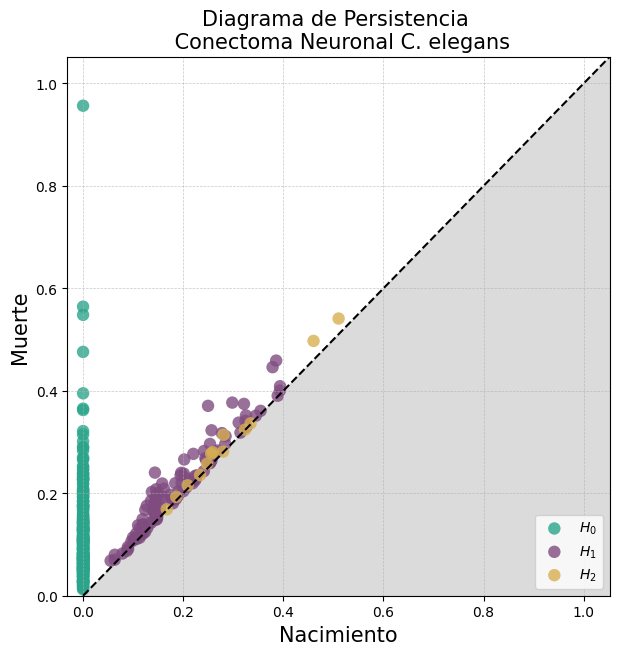

In [104]:
diag=ripser(datos_cluster_0, maxdim=2)['dgms']
graficar_diag(diag, Titulo='Diagrama de Persistencia \n Conectoma Neuronal C. elegans', guardado='Diagrama Persistencia Neuronas')

In [31]:
mats = matrices_LW(datos_cluster_0, method='complete')
diagramas_LW,num_clusters=holografia(mats, maxDim=2)

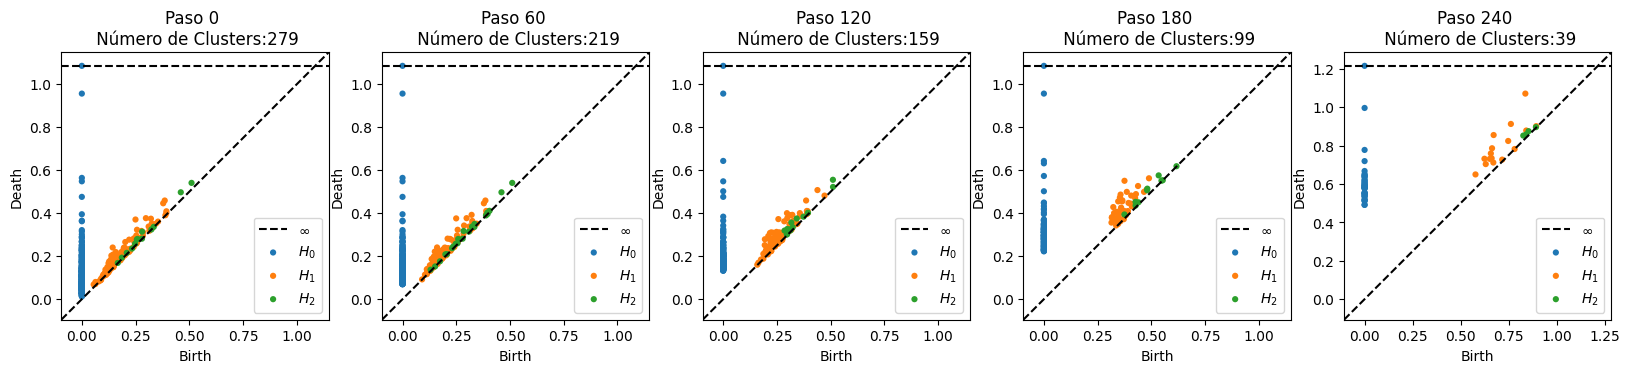

In [32]:
n=5
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

for i in range(n):
    plot_diagrams(diagramas_LW[i*60],  ax=axes[i])
    axes[i].set_title(f"Paso {i*60} \n Número de Clusters:{num_clusters[i*60]}")

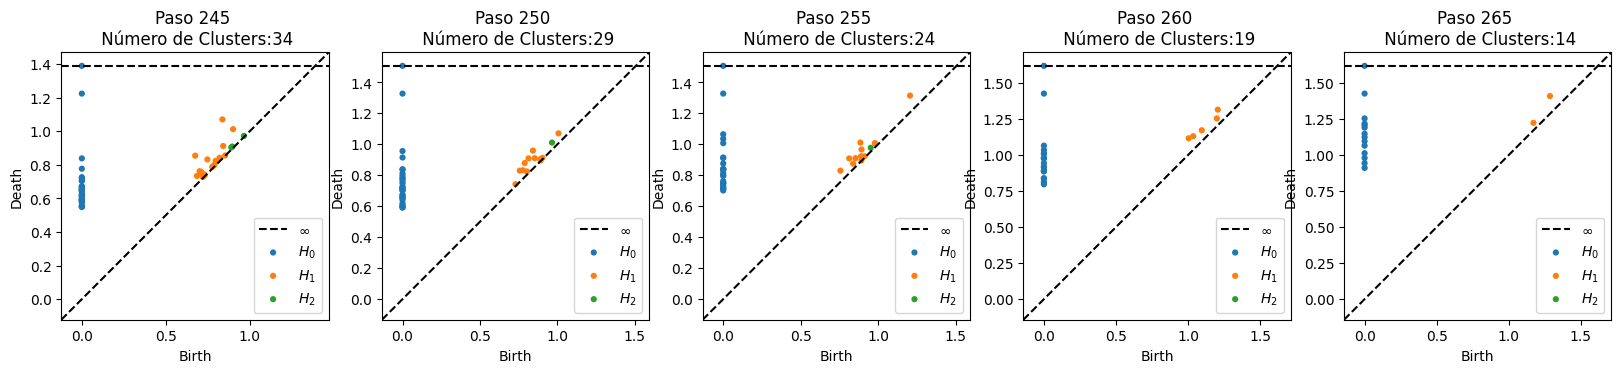

In [79]:
n=5
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

for i in range(n):
    plot_diagrams(diagramas_LW[245+(i*5)],  ax=axes[i])
    axes[i].set_title(f"Paso {245+(i*5)} \n Número de Clusters:{num_clusters[245+(i*5)]}")